In [7]:
import sys
print(sys.executable)

c:\Users\pakra\anaconda3\envs\agentic_langgraph\python.exe


In [15]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END, START
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from dotenv import load_dotenv



In [9]:
from dotenv import load_dotenv
import os

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
google_api_key = os.getenv("GOOGLE_API_KEY")

In [10]:
class RagState(TypedDict):
  queru: str
  documents: List[Document]
  answer: str

In [13]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings  # free, runs locally, tiny

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
    api_key=groq_api_key
)

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"  # downloads once, cached forever
)

c:\Users\pakra\anaconda3\envs\agentic_langgraph\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pakra\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6058.92it/s]


In [14]:
docs = [
    Document(page_content="LangGraph is a framework for building stateful, multi-actor LLM apps."),
    Document(page_content="RAG combines retrieval with generation to ground LLM answers in facts."),
    Document(page_content="Vector databases store embeddings and enable semantic similarity search."),
]

vectorstore = Chroma.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [30]:
def retriever(state: RagState) -> dict:
  """
  Pull relevant docs from vectors store using the query.
  """
  docs = retriever.invoke(state['query'])
  return {'documents':docs}

def generate(state: RagState) -> dict:
    """Build a grounded answer from retrieved docs + query."""
    context = "\n\n".join(d.page_content for d in state["documents"])
    prompt = f"""Answer using ONLY the context below. If unsure, say so.

Context:
{context}

Question: {state["query"]}"""
    
    response = llm.invoke(prompt)
    return {"answer": response.content}

In [31]:
graph = StateGraph(RagState)



graph.add_node('retriever', retriever)
graph.add_node('generate', generate)
graph.set_entry_point('retriever')
graph.add_edge('retriever','generate')
graph.add_edge('generate',END)

app = graph.compile()

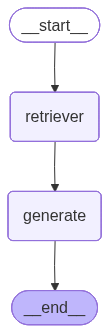

In [32]:
app